[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/edit-state-human-feedback.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239520-lesson-3-editing-state-and-human-feedback)

# Editing graph state

## 回顧

我們先前討論過 human-in-the-loop 的幾個動機：

(1) `Approval`（核准）- 我們可以中斷 agent、把 state 呈現給使用者，並讓使用者決定是否接受某個動作

(2) `Debugging`（除錯）- 我們可以把 graph 倒帶，藉此重現或避開問題

(3) `Editing`（編輯）- 你可以修改 state

我們示範了 breakpoint 如何支援使用者核准，但還不知道在 graph 被中斷後，要怎麼修改 graph state！

## 目標

接下來，我們就來示範如何直接編輯 graph state，並插入 human feedback。

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk langgraph-prebuilt

In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

## Editing state

先前我們介紹了 breakpoint。

我們用 breakpoint 來中斷 graph，並在執行下一個 node 之前等待使用者核准。

但 breakpoint 同時也是[修改 graph state 的好時機](https://docs.langchain.com/oss/javascript/langgraph/use-time-travel#3-update-the-state)。

讓我們把 agent 設定成在 `assistant` node 之前帶有一個 breakpoint。

In [1]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """將 a 和 b 相乘。

    Args:
        a: 第一個 int
        b: 第二個 int
    """
    return a * b

# 這會成為一個 tool
def add(a: int, b: int) -> int:
    """將 a 和 b 相加。

    Args:
        a: 第一個 int
        b: 第二個 int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """將 a 除以 b。

    Args:
        a: 第一個 int
        b: 第二個 int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools)

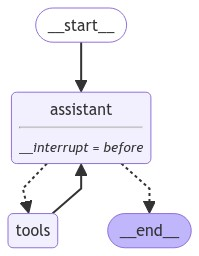

In [2]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

# 給 LLM 的固定開場白。注意它不住在 state 裡，是每次呼叫時才被塞到 messages 最前面，
# 所以它不會進 checkpoint、也不是這章要編輯的對象。這章要改的是 state 裡的 messages。
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# assistant node：整個 graph 裡唯一會呼叫 LLM 的地方
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# 組 graph
builder = StateGraph(MessagesState)

# 定義 node：實際執行工作的就是它們
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# 定義 edge：由它們決定控制流程
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # 如果 assistant 最新的 message（結果）是一個 tool call -> tools_condition 會導向 tools
    # 如果 assistant 最新的 message（結果）不是 tool call -> tools_condition 會導向 END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
# ⚠️ 停的位置跟上一章不一樣，這是本章的重點，講的時候要特別停下來講：
#    上一章 breakpoints 停在 tools 前 → 問的是「這個動作我准不准你做？」（只能 yes / no）
#    這章停在 assistant 前 → 停在「LLM 開口之前」，你能改的是它等下會讀到的輸入本身。
# 換句話說：停在 tools 前你只能否決答案，停在 assistant 前你可以改題目。
#
# 副作用（下一個 cell 的輸出會直接撞到）：START 的下一站就是 assistant，
# 所以第一次 stream 會在「連一次 LLM 都還沒呼叫」的狀態下就停住。
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# 顯示
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

來執行看看！

我們可以看到 graph 在 chat model 回應之前就被中斷了。

In [3]:
# 輸入
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# 執行 graph，直到第一次中斷為止
# 輸出只會印出一句 Human Message 就沒了——這不是壞掉。
# 因為 interrupt_before=["assistant"]，graph 才剛從 START 走到 assistant 門口就被攔下來，
# LLM 這時候連題目都還沒看到。這正是我們要的：趁它還沒讀，先改。
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [4]:
# get_state 撈回來的是 StateSnapshot ——這個瞬間的完整存檔。輸出很長，先認得三個欄位就夠：
#   values → 現在 state 長什麼樣（這裡只有一則 HumanMessage）
#   next   → 下一站要跑誰。現在是 ('assistant',)，這就是「我們確實停在 assistant 門口」的證據
#   config → 裡面藏著 checkpoint_id，也就是這個瞬間的「存檔編號」
#
# checkpoint_id 現在看起來只是一串亂碼，但它是下一章 time travel 的鑰匙：
# 拿著某一個 checkpoint_id 回頭跑，就能從那個瞬間重來一次。這章先讓學員認得它長什麼樣。
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', id='e7edcaba-bfed-4113-a85b-25cc39d6b5a7')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef6a412-5b2d-601a-8000-4af760ea1d0d'}}, metadata={'source': 'loop', 'writes': None, 'step': 0, 'parents': {}}, created_at='2024-09-03T22:09:10.966883+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1ef6a412-5b28-6ace-bfff-55d7a2c719ae'}}, tasks=(PregelTask(id='dbee122a-db69-51a7-b05b-a21fab160696', name='assistant', error=None, interrupts=(), state=None),))

現在，我們可以直接套用一次 state 更新。

記住，對 `messages` key 的更新會使用 `add_messages` 這個 reducer：
 
* 如果我們想覆寫既有的 message，可以提供該 message 的 `id`。
* 如果我們只是想把新訊息附加到 messages 清單後面，那就傳入一個沒有指定 `id` 的 message，如下所示。

In [5]:
# ⚠️ 踩雷：這是本章最大的地雷。update_state 這個名字聽起來像「設定 state」，
#    但它實際做的是「丟一份更新進去，讓 reducer 決定怎麼併」——併法不是你決定的。
#    messages 這個 key 帶了 add_messages reducer，而 add_messages 對「沒有 id 的新 message」
#    的預設動作是：附加到列表尾巴。
#
# 所以這行跑完，state 裡是「Multiply 2 and 3」和「No, actually multiply 3 and 3!」兩則都在，
# 不是後者取代前者。下一個 cell 印出全部 messages，就是要學員親眼看到這件事。
#
# 類比：你不是在改一份文件，你是往收件匣再投一封信——怎麼歸檔是 reducer 的事，不是你的事。
#
# 那為什麼結果看起來還是對的？因為兩則都會送進 LLM，它自然聽最後一句。
# 但舊訊息永遠留在歷史裡。真的要讓它消失（覆寫），得帶著既有 message 的 id 送回去——
# 本 notebook 後半段的 SDK 版就是那樣做的，等下對照著看。
graph.update_state(
    thread,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3!")]},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1ef6a414-f419-6182-8001-b9e899eca7e5'}}

來看看結果。

我們用一個新的 message 呼叫了 `update_state`。

`add_messages` reducer 會把它附加到我們的 state key `messages` 後面。

In [6]:
# 這裡刻意印「全部」messages，不是只印最後一則。
# 上面那句 update_state 到底是「換掉」還是「加一筆」，答案就在這個輸出：兩則 HumanMessage 都在。
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No, actually multiply 3 and 3!


現在，我們只要傳入 `None`，讓 agent 從目前的 state 繼續往下執行。

我們會先送出目前的狀態，接著繼續執行剩下的 node。

In [7]:
# 第一個參數傳 None = 「續跑」，不是「重跑」。
# 這是最反直覺的一行：Python 直覺會把 None 讀成「沒有輸入」，
# 但對 LangGraph 來說 None 的意思是「別給我新輸入，從 checkpoint 存的 state 接著跑」。
# ⚠️ 踩雷：這裡如果手癢再傳一次 initial_input，等於又往 messages 塞一則「Multiply 2 and 3」，
#    對話會歪掉，而且不會報錯。
#
# 為什麼跑到 tool 算出 9 就停了？看 graph 結構：assistant → tools → assistant，這是一個迴圈。
# 而 interrupt_before=["assistant"] 的意思是「每次要進 assistant 都停」，不是「只停第一次」。
# 這一輪跑的是：assistant（吐出 tool call）→ tools（算出 9）→ 準備回 assistant → 停。
# 這就是為什麼下面還要再跑一次一模一樣的程式碼。
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 3 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (call_Mbu8MfA0krQh8rkZZALYiQMk)
 Call ID: call_Mbu8MfA0krQh8rkZZALYiQMk
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


現在，我們又回到帶有 `breakpoint` 的 `assistant`。

我們可以再次傳入 `None` 來繼續往下執行。

In [8]:
# 對，這個 cell 跟上一個一字不差，不是複製貼上出錯。學員一定會問，先講在前面。
# 上一輪停在 assistant 門口，這一輪再 None 續跑一次，放行 assistant：
# 它讀到 tool 算出來的 9，講成人話，然後走到 END。
# 一句話總結：breakpoint 不是「停一次」，是「每次經過都停」。迴圈繞幾圈，你就得放行幾次。
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

3 multiplied by 3 equals 9.


### 在 Studio 中編輯 graph state

**⚠️ 注意**

在拍攝這些影片之後，我們更新了 Studio，現在它可以在本機執行並透過瀏覽器存取。這也是建議的執行方式，取代影片中所示的桌面版 App。它現在叫做 _LangSmith Studio_，而不再是 _LangGraph Studio_。詳細的設定說明可在課程開頭的「Getting Setup」指南中找到。你可以在[這裡](https://docs.langchain.com/langsmith/studio)找到關於 Studio 的說明，並在[這裡](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)找到本機部署的具體細節。  
要啟動本機開發伺服器，請在終端機中切換到本模組的 `/studio` 目錄，並執行以下指令：

```
langgraph dev
```

你應該會看到以下輸出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打開你的瀏覽器，前往上方顯示的 **Studio UI** 網址。

LangGraph API [支援編輯 graph state](https://docs.langchain.com/langsmith/add-human-in-the-loop)。

In [ ]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

In [9]:
# 這是本機開發伺服器的 URL
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

我們的 agent 定義在 `studio/agent.py` 裡。

如果你看一下程式碼，會發現它*並沒有* breakpoint！
 
當然，我們可以把它加進 `agent.py`，但這個 API 有個很棒的特性：我們可以直接傳入一個 breakpoint！

這裡，我們傳入 `interrupt_before=["assistant"]`。

In [10]:
initial_input = {"messages": "Multiply 2 and 3"}
thread = await client.threads.create()
async for chunk in client.runs.stream(
    thread["thread_id"],
    "agent",
    input=initial_input,
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46', 'example': False}
--------------------------------------------------


我們可以取得目前的 state

In [11]:
current_state = await client.threads.get_state(thread['thread_id'])
current_state

{'values': {'messages': [{'content': 'Multiply 2 and 3',
    'additional_kwargs': {},
    'response_metadata': {},
    'type': 'human',
    'name': None,
    'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
    'example': False}]},
 'next': ['assistant'],
 'tasks': [{'id': 'a71c0b80-a679-57cb-aa59-a1655b763480',
   'name': 'assistant',
   'error': None,
   'interrupts': [],
   'state': None}],
 'metadata': {'step': 0,
  'run_id': '1ef6a41c-ea63-663f-b3e8-4f001bf0bf53',
  'source': 'loop',
  'writes': None,
  'parents': {},
  'user_id': '',
  'graph_id': 'agent',
  'thread_id': 'a95ffa54-2435-4a47-a9da-e886369ca8ee',
  'created_by': 'system',
  'assistant_id': 'fe096781-5601-53d2-b2f6-0d3403f7e9ca'},
 'created_at': '2024-09-03T22:13:54.466695+00:00',
 'checkpoint_id': '1ef6a41c-ead7-637b-8000-8c6a7b98379e',
 'parent_checkpoint_id': '1ef6a41c-ead3-637d-bfff-397ebdb4f2ea'}

我們可以看看 state 中的最後一則 message。

In [12]:
# 注意這行抓下來的是「整包 message」，不是只有 content —— 裡面連 id 都一起帶出來了。
# 那個 id 等一下就是「覆寫」和「附加」的分水嶺，是這段 SDK 示範的全部關鍵。
last_message = current_state['values']['messages'][-1]
last_message

{'content': 'Multiply 2 and 3',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
 'example': False}

我們可以編輯它！

In [13]:
# 只動 content，id 一個字都沒碰。這是刻意的，不是偷懶——原因看下面 update_state 那個 cell。
last_message['content'] = "No, actually multiply 3 and 3!"
last_message

{'content': 'No, actually multiply 3 and 3!',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
 'example': False}

In [14]:
last_message

{'content': 'No, actually multiply 3 and 3!',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
 'example': False}

記住，就像我們前面說過的，對 `messages` key 的更新一樣會使用 `add_messages` reducer。

如果我們想覆寫既有的 message，就可以提供該 message 的 `id`。

這裡我們就是這麼做的。如上所示，我們只修改了 message 的 `content`。

In [15]:
# ⚠️ 這裡的行為跟前面本機版「相反」：本機版是附加，這次是覆寫。
#    兩邊看起來都只是 update_state，差別到底在哪？答案只有一個字：id。
#
# add_messages reducer 的規則就這兩條：
#    你送回來的 message 帶的 id 和既有某一則相同 → 覆寫那一則（原地換掉）
#    id 不同，或根本沒給 id                      → 當成新訊息，附加到尾巴
#
# 前面本機版寫的是 HumanMessage(content=...)，LangChain 自動配了一個新 id → 所以是附加。
# 這裡是把原本那則整包撈出來、只改 content、id 原封不動送回去 → 所以是覆寫。
# 跑完 state 裡只有一則 message，「Multiply 2 and 3」在歷史上等於沒發生過。
#
# 這是下一章 time travel「fork」的前置知識：改寫歷史 vs 追加歷史，分界線就是這個 id。
await client.threads.update_state(thread['thread_id'], {"messages": last_message})

{'configurable': {'thread_id': 'a95ffa54-2435-4a47-a9da-e886369ca8ee',
  'checkpoint_ns': '',
  'checkpoint_id': '1ef6a41d-cc8e-6979-8001-8c7c283b636c'},
 'checkpoint_id': '1ef6a41d-cc8e-6979-8001-8c7c283b636c'}

現在，我們傳入 `None` 來繼續往下執行。

In [16]:
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': 'No, actually multiply 3 and 3!', 'additional_kwargs': {'additional_kwargs': {}, 'response_metadata': {}, 'example': False}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46', 'example': False}
--------------------------------------------------
Receiving new event of type: values...
{'content': '', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_vi16je2EIikHuT7Aue2sd1qd', 'function': {'arguments': '{"a":3,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai', 'name': None, 'id': 'run-775b42f7-0590-4c54-aaeb-78599b1f12d2', 'example': False, 'tool_calls': [{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': 'call_vi16je2EIikHuT7Aue2sd1qd', 'type

正如預期，我們拿到了 tool call 的結果 `9`。

In [17]:
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': '9', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '226bfbad-0cea-4900-80c5-761a62bd4bc1', 'tool_call_id': 'call_vi16je2EIikHuT7Aue2sd1qd', 'artifact': None, 'status': 'success'}
--------------------------------------------------
Receiving new event of type: values...
{'content': 'The result of multiplying 3 by 3 is 9.', 'additional_kwargs': {}, 'response_metadata': {'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai', 'name': None, 'id': 'run-859bbf47-9f35-4e71-ae98-9d93ee49d16c', 'example': False, 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': None}
--------------------------------------------------


## 等待使用者輸入

所以，很明顯地，我們可以在 breakpoint 之後編輯 agent 的 state。

那麼，如果我們想讓 human feedback 來執行這個 state 更新呢？

我們會在 agent 中加入一個 node，作為 human feedback 的佔位點。

這個 `human_feedback` node 讓使用者可以把回饋直接加進 state。
 
我們透過在 `human_feedback` node 上使用 `interrupt_before` 來指定 breakpoint。

我們設定一個 checkpointer，把直到這個 node 為止的 graph state 都儲存起來。

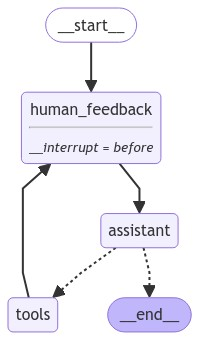

In [18]:
# 給 LLM 的固定開場白（同上半段，沒變）
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# 學員必問：一個 pass、什麼都不做、連 return 都沒有的 node，存在幹嘛？
# 答案：它唯一的用途是當一個「可以掛 interrupt 的門牌」。
# interrupt_before 必須指名一個 node 才停得下來，所以你想讓人類在某個位置插話，
# 就得先在那個位置立一塊牌子。它不做事，它只是一個停車格。
def human_feedback(state: MessagesState):
    pass

# assistant node：唯一會呼叫 LLM 的地方
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# 組 graph
builder = StateGraph(MessagesState)

# 定義 node：實際執行工作的就是它們
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)

# 定義 edge：由它們決定控制流程
builder.add_edge(START, "human_feedback")
builder.add_edge("human_feedback", "assistant")
builder.add_conditional_edges(
    "assistant",
    # 如果 assistant 最新的 message（結果）是一個 tool call -> tools_condition 會導向 tools
    # 如果 assistant 最新的 message（結果）不是 tool call -> tools_condition 會導向 END
    tools_condition,
)
# 這條 edge 是本段的形狀關鍵：把迴圈接成 human_feedback → assistant → tools → human_feedback。
# 對照上半段的 graph 是 tools → assistant（人類只在最開頭插話一次，之後 agent 自己跑到底）；
# 這裡改成 tools → human_feedback，意思是每做完一輪工具呼叫，方向盤就交回人類手上一次。
builder.add_edge("tools", "human_feedback")

memory = MemorySaver()
# 門牌換人：上半段停在 assistant（趁 LLM 開口前偷改輸入），
# 這裡停在 human_feedback（在流程裡正式保留一個屬於人類的回合）。
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

我們會向使用者取得回饋。

和先前一樣，我們用 `.update_state` 把取得的 human 回應更新進 graph 的 state。

我們使用 `as_node="human_feedback"` 這個參數，讓這次的 state 更新以指定的 node（也就是 `human_feedback`）名義套用。

In [19]:
# 輸入
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# 執行 graph，直到第一次中斷為止（START 的下一站就是 human_feedback，所以馬上就停）
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    
# 取得使用者輸入
user_input = input("Tell me how you want to update the state: ")

# ⚠️ as_node= 是整個 module-3 最隱晦的參數，不查文件絕對看不出它在幹嘛。
#    它的意思是：「假裝這筆更新是 human_feedback 這個 node 寫出來的。」
#
# 為什麼非寫不可？因為 graph 續跑時，是靠「上一個跑完的 node 是誰」來決定下一站往哪走。
# 冒充成 human_feedback，graph 才會照著 human_feedback → assistant 這條 edge 接下去。
# 不寫 as_node，graph 不知道該從哪一站接，就走不到 assistant。
#
# 類比：在流程單上蓋別人的章，讓後面的關卡以為那一關已經過了。
#
# 順帶一提：user_input 是純字串，add_messages 會自動把它包成 HumanMessage。
# 沒有 id → 依照前面那條規則，這是附加，不是覆寫（原本的「Multiply 2 and 3」還在）。
graph.update_state(thread, {"messages": user_input}, as_node="human_feedback")

# 繼續執行 graph
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

no, multiply 3 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_sewrDyCrAJBQQecusUoT6OJ6)
 Call ID: call_sewrDyCrAJBQQecusUoT6OJ6
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


In [20]:
# 又是 None 續跑。上一個 cell 最後跑完 tools 後，迴圈繞回 human_feedback 門口又停住了。
# 這一輪放行，但這次沒人插話——沒呼叫 update_state，human_feedback 就真的什麼都不做地跑過去，
# 直接進 assistant 讓它把 9 講成人話。這正好示範了那個 no-op node 的本質：它只是個停車格。
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

The result of multiplying 3 and 3 is 9.
